<a href="https://colab.research.google.com/github/smjason0502/python-deep-learning-pytorch/blob/main/Pytorch_%ED%99%9C%EC%9A%A9_Timeseries_%EC%98%88%EC%B8%A1_%EC%9D%B4%EC%8A%B9%EB%AF%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
input_list = [ [ [1,2],[2,3],[3,4] ], [ [5,6], [6,7], [7,8] ] ]
label_list = [10, 20]

In [2]:
#5.  RNN numpy 데이터 생성
import numpy as np

x_data = np.array(input_list)
y_data = np.array(label_list)

print(x_data.shape, y_data.shape)

(2, 3, 2) (2,)


In [3]:
#5.  RNN TensorDataset 데이터 생성
import torch
from torch.utils.data import TensorDataset

x_data = torch.FloatTensor(input_list)
y_data = torch.FloatTensor(label_list)

print(x_data.size(), y_data.size())

dataset = TensorDataset(x_data, y_data)

torch.Size([2, 3, 2]) torch.Size([2])


In [4]:
import torch

input_data = torch.Tensor([ [ [1], [2], [3] ] ]) # (1, 3, 1) shape 을 가지는 입력데이터


MyRNNModel = torch.nn.RNN(input_size=1, hidden_size=3,  # 입력으로 1개의 feature, 출력으로 3개의 hidden state를 가지는 RNN 레이어
                          batch_first=True)


outputs, last_hs = MyRNNModel(input_data)  # 첫번째 리턴값 outputs은 모든 시점(timesteps)의 hidden state들이며, 두번째 리턴값 last_hs는 마지막 시점 (timestep)의 hidden state. 즉 outputs 은 [ h1, h2, h3 ]이며 last_hs 는 [ h3 ] 를 나타냄

print(outputs.shape, '\n\n', outputs, '\n')
print(last_hs.shape,'\n\n', last_hs)

torch.Size([1, 3, 3]) 

 tensor([[[ 0.7260,  0.4166, -0.5551],
         [ 0.8668,  0.1986, -0.6987],
         [ 0.9500,  0.1955, -0.7226]]], grad_fn=<TransposeBackward1>) 

torch.Size([1, 1, 3]) 

 tensor([[[ 0.9500,  0.1955, -0.7226]]], grad_fn=<StackBackward0>)


In [5]:
import torch

input_data = torch.Tensor([ [ [1], [2], [3] ],
                            [ [4], [5], [6] ] ])


MyRNNModel = torch.nn.RNN(input_size=1, hidden_size=3,
                          batch_first=True)


outputs, last_hs = MyRNNModel(input_data)

print(outputs.shape, '\n\n', outputs, '\n')
print(last_hs.shape,'\n\n', last_hs)

torch.Size([2, 3, 3]) 

 tensor([[[-0.4260,  0.3551, -0.0612],
         [-0.7786,  0.7330,  0.2816],
         [-0.9289,  0.9075,  0.5674]],

        [[-0.9451,  0.9212,  0.6765],
         [-0.9894,  0.9845,  0.8540],
         [-0.9959,  0.9936,  0.9183]]], grad_fn=<TransposeBackward1>) 

torch.Size([1, 2, 3]) 

 tensor([[[-0.9289,  0.9075,  0.5674],
         [-0.9959,  0.9936,  0.9183]]], grad_fn=<StackBackward0>)


In [6]:
import torch

input_data = torch.Tensor([ [ [1], [2], [3] ],
                            [ [4], [5], [6] ],
                            [ [7], [8], [9] ] ])


MyRNNModel = torch.nn.RNN(input_size=1, hidden_size=3,
                          batch_first=True)


outputs, last_hs = MyRNNModel(input_data)

print(outputs.shape, '\n\n', outputs, '\n')
print(last_hs.shape,'\n\n', last_hs)

torch.Size([3, 3, 3]) 

 tensor([[[-0.1416,  0.0852,  0.6308],
         [-0.3368,  0.6122,  0.7067],
         [-0.5970,  0.8526,  0.8225]],

        [[-0.9231,  0.8970,  0.9184],
         [-0.9335,  0.9865,  0.9114],
         [-0.9732,  0.9946,  0.9494]],

        [[-0.9958,  0.9930,  0.9841],
         [-0.9961,  0.9992,  0.9820],
         [-0.9985,  0.9997,  0.9897]]], grad_fn=<TransposeBackward1>) 

torch.Size([1, 3, 3]) 

 tensor([[[-0.5970,  0.8526,  0.8225],
         [-0.9732,  0.9946,  0.9494],
         [-0.9985,  0.9997,  0.9897]]], grad_fn=<StackBackward0>)


In [7]:
## 예제 1. LSTM을 이용한 삼성전자 주가 예측
import torch
import numpy as np
import pandas as pd
from torch import nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

In [8]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f"using PyTorch version: {torch.__version__}, Device: {DEVICE}")

using PyTorch version: 2.4.0+cpu, Device: cpu


In [9]:
FEATURE_NUMS = 4        # 입력층으로 들어가는 데이터 개수 feature
SEQ_LENGTH = 5          # 정답을 만들기 위해 필요한 시점 개수 time step
HIDDEN_SIZE = 4         # RNN 계열 계층을 구성하는 hidden state 개수
NUM_LAYERS = 1          # RNN 계열 계층이 몇겹으로 쌓였는지 나타냄
LEARNING_RATE = 1e-3    # 학습율
BATCH_SIZE = 20         # 학습을 위한 배치사이즈 개수

In [11]:
pip install finance-datareader

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.3/89.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.0/5.0 MB 53.0 MB/s eta 0:00:00


In [12]:
import FinanceDataReader as fdr

df = fdr.DataReader('005930', '2020-01-01', '2024-06-30')

df = df[ ['Open', 'High', 'Low', 'Volume', 'Close'] ]

df.head(10)

,Open,High,Low,Volume,Close
Date,,,,,
2020-01-02,55500,56000,55000,12993228,55200
2020-01-03,56000,56600,54900,15422255,55500
2020-01-06,54900,55600,54600,10278951,55500
2020-01-07,55700,56400,55600,10009778,55800
2020-01-08,56200,57400,55900,23501171,56800
2020-01-09,58400,58600,57400,24102579,58600
2020-01-10,58800,59700,58300,16000170,59500
2020-01-13,59600,60000,59100,11359139,60000
2020-01-14,60400,61000,59900,16906295,60000


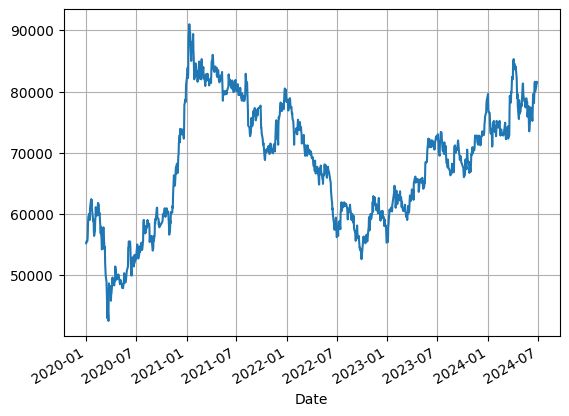

In [13]:
df['Close'].plot().grid()

In [14]:
# train : test - 70 : 30 분리

SPLIT = int(0.7*len(df))  # train : test = 7 : 3

train_df = df[ :SPLIT ]
test_df = df[ SPLIT: ]

In [15]:
scaler_x = MinMaxScaler()  # feature scaling

train_df.iloc[ : , :-1 ] = scaler_x.fit_transform(train_df.iloc[ : , :-1 ])
test_df.iloc[ : , :-1 ] = scaler_x.fit_transform(test_df.iloc[ : , :-1 ])

scaler_y = MinMaxScaler()  # label scaling

train_df.iloc[ : , -1 ] = scaler_y.fit_transform(train_df.iloc[ : , [-1] ])
test_df.iloc[ : , -1 ] = scaler_y.fit_transform(test_df.iloc[ : , [-1] ])

<ipython-input-15-35f76efdda21>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.27044025 0.28092243 0.25786164 0.27463312 0.2851153  0.3312369
 0.33962264 0.35639413 0.37316562 0.35429769 0.34591195 0.40461216
 0.4067086  0.4067086  0.37526205 0.40251572 0.35220126 0.34591195
 0.33962264 0.31865828 0.27044025 0.30398323 0.36477987 0.36687631
 0.38784067 0.34800839 0.360587   0.37106918 0.38993711 0.3836478
 0.39832285 0.38155136 0.360587   0.37945493 0.33962264 0.31027254
 0.2851153  0.28092243 0.28721174 0.25995807 0.24528302 0.29559748
 0.2557652  0.31446541 0.29140461 0.25366876 0.23480084 0.24528302
 0.17610063 0.10167715 0.1572327  0.09014675 0.10796646 0.07966457
 0.03249476 0.         0.02620545 0.13312369 0.13417191 0.14675052
 0.0932914  0.11320755 0.10167715 0.0754717  0.10062893 0.10272537
 0.14779874 0.14675052 0.14989518 0.13312369 0.12683438 0.12997904
 0.14150943 0.17190776 0.18448637 0.14255765 

In [16]:
def MakeSeqNumpyData(data, seq_length):

    x_seq_list = []
    y_seq_list = []

    for i in range(len(data) - seq_length):
        x_seq_list.append(data[ i:i+seq_length, :-1 ])
        y_seq_list.append(data[ i+seq_length, [-1] ])

    x_seq_numpy = np.array(x_seq_list)
    y_seq_numpy = np.array(y_seq_list)

    return x_seq_numpy, y_seq_numpy

In [17]:
x_train_data, y_train_data = MakeSeqNumpyData(np.array(train_df), SEQ_LENGTH)

x_test_data, y_test_data = MakeSeqNumpyData(np.array(test_df), SEQ_LENGTH)

print(x_train_data.shape, y_train_data.shape)
print(x_test_data.shape, y_test_data.shape)

(770, 5, 4) (770, 1)
(328, 5, 4) (328, 1)


In [18]:
x_train_tensor = torch.FloatTensor(x_train_data).to(DEVICE)
y_train_tensor = torch.FloatTensor(y_train_data).to(DEVICE)

x_test_tensor = torch.FloatTensor(x_test_data).to(DEVICE)
y_test_tensor = torch.FloatTensor(y_test_data).to(DEVICE)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
class MyLSTMModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, data):
        h0 = torch.zeros(self.num_layers, data.size(0), self.hidden_size).to(DEVICE)
        c0 = torch.zeros(self.num_layers, data.size(0), self.hidden_size).to(DEVICE)

        outputs, _ = self.lstm(data, (h0, c0))
        last_hs = outputs[:, -1, :]
        prediction = self.fc(last_hs)

        return prediction

In [20]:
model = MyLSTMModel(FEATURE_NUMS, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [21]:
def model_train(dataloader, model, loss_function, optimizer):

    model.train()

    train_loss_sum = 0

    total_train_batch = len(dataloader)

    for inputs, labels in dataloader:

        x_train = inputs.to(DEVICE)
        y_train = labels.to(DEVICE)

        outputs = model(x_train)
        loss = loss_function(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    train_avg_loss = train_loss_sum / total_train_batch

    return train_avg_loss

In [22]:
def model_evaluate(dataloader, model, loss_function, optimizer):

    model.eval()

    with torch.no_grad():

        val_loss_sum = 0

        total_val_batch = len(dataloader)

        for inputs, labels in dataloader:

            x_val = inputs.to(DEVICE)
            y_val = labels.to(DEVICE)

            outputs = model(x_val)
            loss = loss_function(outputs, y_val)

            val_loss_sum += loss.item()

        val_avg_loss = val_loss_sum / total_val_batch

    return val_avg_loss

In [23]:
from datetime import datetime

train_loss_list = []

start_time = datetime.now()

EPOCHS = 200

for epoch in range(EPOCHS):

    avg_loss = model_train(train_loader, model, loss_function, optimizer)

    train_loss_list.append(avg_loss)

    if (epoch % 10 == 0):
        print('epoch: ', epoch, ', train loss = ', avg_loss)

end_time = datetime.now()

print('elapsed time => ', end_time-start_time)

epoch:  0 , train loss =  0.17755585585314876
epoch:  10 , train loss =  0.013250809209869029
epoch:  20 , train loss =  0.0015317463787654655
epoch:  30 , train loss =  0.0013031018174026543
epoch:  40 , train loss =  0.001182976348597246
epoch:  50 , train loss =  0.0011172711182063301
epoch:  60 , train loss =  0.0010795725441615407
epoch:  70 , train loss =  0.001056361213648835
epoch:  80 , train loss =  0.0010399975249012455
epoch:  90 , train loss =  0.0010251690050025876
epoch:  100 , train loss =  0.0010090235808046344
epoch:  110 , train loss =  0.0009911776350912615
epoch:  120 , train loss =  0.0009722376528840798
epoch:  130 , train loss =  0.0009526131870165372
epoch:  140 , train loss =  0.0009326834868914328
epoch:  150 , train loss =  0.0009130035338248723
epoch:  160 , train loss =  0.0008941021929226386
epoch:  170 , train loss =  0.0008762699080995308
epoch:  180 , train loss =  0.0008596271110059789
epoch:  190 , train loss =  0.0008440526349332709
elapsed time => 

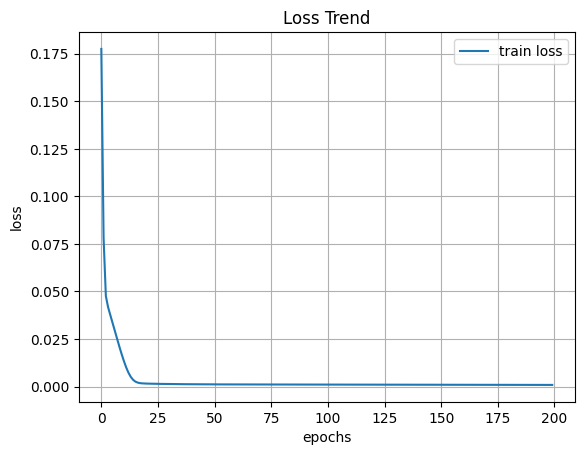

In [24]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(train_loss_list, label='train loss')
plt.legend()
plt.show()

In [25]:
test_pred_tensor = model(x_test_tensor)

test_pred_numpy = test_pred_tensor.cpu().detach().numpy()

pred_inverse = scaler_y.inverse_transform(test_pred_numpy)

y_test_numpy = y_test_tensor.cpu().detach().numpy()

y_test_inverse = scaler_y.inverse_transform(y_test_numpy)

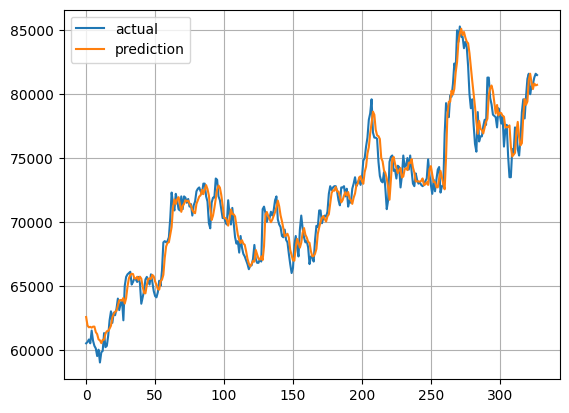

In [26]:
import matplotlib.pyplot as plt

plt.plot(y_test_inverse, label='actual')
plt.plot(pred_inverse, label='prediction')
plt.grid()
plt.legend()

plt.show()

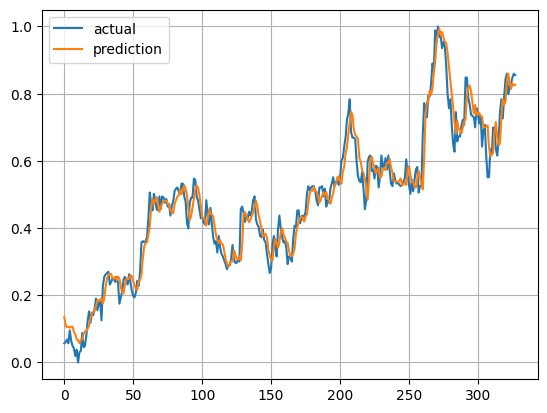

In [27]:
import matplotlib.pyplot as plt

plt.plot(y_test_numpy, label='actual')
plt.plot(test_pred_numpy, label='prediction')
plt.grid()
plt.legend()

plt.show()

In [28]:
# 예제 2. GRU를 이용한 삼성전자 주가 예측
import torch
import numpy as np
import pandas as pd
from torch import nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from torch.utils.data import TensorDataset, DataLoader

In [29]:
DEVICE = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")

print(f"using PyTorch version: {torch.__version__}, Device: {DEVICE}")

using PyTorch version: 2.4.0+cpu, Device: cpu


In [30]:
FEATURE_NUMS = 4        # 입력층으로 들어가는 데이터 개수 feature
SEQ_LENGTH = 5          # 정답을 만들기 위해 필요한 시점 개수 time step
HIDDEN_SIZE = 4         # RNN 계열 계층을 구성하는 hidden state 개수
NUM_LAYERS = 1          # RNN 계열 계층이 몇겹으로 쌓였는지 나타냄
LEARNING_RATE = 1e-3    # 학습율
BATCH_SIZE = 20         # 학습을 위한 배치사이즈 개수

In [31]:
# pip install finance-datareader
import FinanceDataReader as fdr

df = fdr.DataReader('005930', '2020-01-01', '2024-06-30')

df = df[ ['Open', 'High', 'Low', 'Volume', 'Close'] ]

df.head(10)

,Open,High,Low,Volume,Close
Date,,,,,
2020-01-02,55500,56000,55000,12993228,55200
2020-01-03,56000,56600,54900,15422255,55500
2020-01-06,54900,55600,54600,10278951,55500
2020-01-07,55700,56400,55600,10009778,55800
2020-01-08,56200,57400,55900,23501171,56800
2020-01-09,58400,58600,57400,24102579,58600
2020-01-10,58800,59700,58300,16000170,59500
2020-01-13,59600,60000,59100,11359139,60000
2020-01-14,60400,61000,59900,16906295,60000


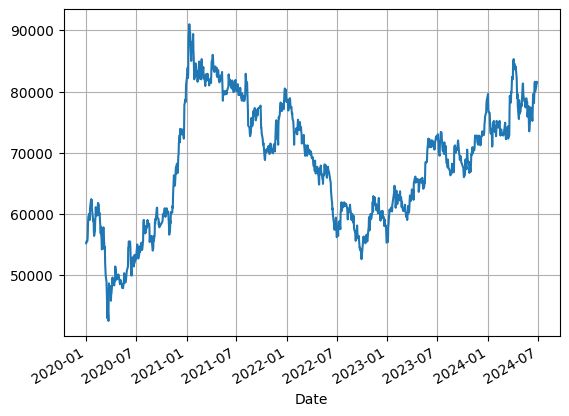

In [32]:
df['Close'].plot().grid()

In [33]:
# train : test - 70 : 30 분리

SPLIT = int(0.7*len(df))  # train : test = 7 : 3

train_df = df[ :SPLIT ]
test_df = df[ SPLIT: ]

In [34]:
scaler_x = MinMaxScaler()  # feature scaling

train_df.iloc[ : , :-1 ] = scaler_x.fit_transform(train_df.iloc[ : , :-1 ])
test_df.iloc[ : , :-1 ] = scaler_x.fit_transform(test_df.iloc[ : , :-1 ])

scaler_y = MinMaxScaler()  # label scaling

train_df.iloc[ : , -1 ] = scaler_y.fit_transform(train_df.iloc[ : , [-1] ])
test_df.iloc[ : , -1 ] = scaler_y.fit_transform(test_df.iloc[ : , [-1] ])

<ipython-input-34-35f76efdda21>:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[0.27044025 0.28092243 0.25786164 0.27463312 0.2851153  0.3312369
 0.33962264 0.35639413 0.37316562 0.35429769 0.34591195 0.40461216
 0.4067086  0.4067086  0.37526205 0.40251572 0.35220126 0.34591195
 0.33962264 0.31865828 0.27044025 0.30398323 0.36477987 0.36687631
 0.38784067 0.34800839 0.360587   0.37106918 0.38993711 0.3836478
 0.39832285 0.38155136 0.360587   0.37945493 0.33962264 0.31027254
 0.2851153  0.28092243 0.28721174 0.25995807 0.24528302 0.29559748
 0.2557652  0.31446541 0.29140461 0.25366876 0.23480084 0.24528302
 0.17610063 0.10167715 0.1572327  0.09014675 0.10796646 0.07966457
 0.03249476 0.         0.02620545 0.13312369 0.13417191 0.14675052
 0.0932914  0.11320755 0.10167715 0.0754717  0.10062893 0.10272537
 0.14779874 0.14675052 0.14989518 0.13312369 0.12683438 0.12997904
 0.14150943 0.17190776 0.18448637 0.14255765 

In [35]:
def MakeSeqNumpyData(data, seq_length):

    x_seq_list = []
    y_seq_list = []

    for i in range(len(data) - seq_length):
        x_seq_list.append(data[ i:i+seq_length, :-1 ])
        y_seq_list.append(data[ i+seq_length, [-1] ])

    x_seq_numpy = np.array(x_seq_list)
    y_seq_numpy = np.array(y_seq_list)

    return x_seq_numpy, y_seq_numpy

In [36]:
x_train_data, y_train_data = MakeSeqNumpyData(np.array(train_df), SEQ_LENGTH)

x_test_data, y_test_data = MakeSeqNumpyData(np.array(test_df), SEQ_LENGTH)

print(x_train_data.shape, y_train_data.shape)
print(x_test_data.shape, y_test_data.shape)

(770, 5, 4) (770, 1)
(328, 5, 4) (328, 1)


In [37]:
x_train_tensor = torch.FloatTensor(x_train_data).to(DEVICE)
y_train_tensor = torch.FloatTensor(y_train_data).to(DEVICE)

x_test_tensor = torch.FloatTensor(x_test_data).to(DEVICE)
y_test_tensor = torch.FloatTensor(y_test_data).to(DEVICE)

train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

train_loader = DataLoader(dataset=train_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(dataset=test_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [38]:
class MyGRUModel(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers):
        super().__init__()
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)

    def forward(self, data):
        h0 = torch.zeros(self.num_layers, data.size(0), self.hidden_size).to(DEVICE)

        outputs, _ = self.gru(data, h0)
        last_hs = outputs[:, -1, :]
        prediction = self.fc(last_hs)

        return prediction

In [39]:
model = MyGRUModel(FEATURE_NUMS, HIDDEN_SIZE, NUM_LAYERS).to(DEVICE)

loss_function = nn.MSELoss()

optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

In [40]:
def model_train(dataloader, model, loss_function, optimizer):

    model.train()

    train_loss_sum = 0

    total_train_batch = len(dataloader)

    for inputs, labels in dataloader:

        x_train = inputs.to(DEVICE)
        y_train = labels.to(DEVICE)

        outputs = model(x_train)
        loss = loss_function(outputs, y_train)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss_sum += loss.item()

    train_avg_loss = train_loss_sum / total_train_batch

    return train_avg_loss

In [41]:
def model_evaluate(dataloader, model, loss_function, optimizer):

    model.eval()

    with torch.no_grad():

        val_loss_sum = 0

        total_val_batch = len(dataloader)

        for inputs, labels in dataloader:

            x_val = inputs.to(DEVICE)
            y_val = labels.to(DEVICE)

            outputs = model(x_val)
            loss = loss_function(outputs, y_val)

            val_loss_sum += loss.item()

        val_avg_loss = val_loss_sum / total_val_batch

    return val_avg_loss

In [42]:
from datetime import datetime

train_loss_list = []

start_time = datetime.now()

EPOCHS = 200

for epoch in range(EPOCHS):

    avg_loss = model_train(train_loader, model, loss_function, optimizer)

    train_loss_list.append(avg_loss)

    if (epoch % 10 == 0):
        print('epoch: ', epoch, ', train loss = ', avg_loss)

end_time = datetime.now()

print('elapsed time => ', end_time-start_time)

epoch:  0 , train loss =  0.3131481368476764
epoch:  10 , train loss =  0.02731168687862989
epoch:  20 , train loss =  0.0031867120429897346
epoch:  30 , train loss =  0.0009950443964976913
epoch:  40 , train loss =  0.0009513616178316089
epoch:  50 , train loss =  0.0009250200610273542
epoch:  60 , train loss =  0.0009112013988972952
epoch:  70 , train loss =  0.0009021093477106964
epoch:  80 , train loss =  0.0008921530060410404
epoch:  90 , train loss =  0.0008801339356115279
epoch:  100 , train loss =  0.0008671149426402572
epoch:  110 , train loss =  0.0008542357174566207
epoch:  120 , train loss =  0.000842034705923512
epoch:  130 , train loss =  0.000830618737008757
epoch:  140 , train loss =  0.0008198591296184951
epoch:  150 , train loss =  0.00080958722892086
epoch:  160 , train loss =  0.0007996703311502456
epoch:  170 , train loss =  0.0007900550147333445
epoch:  180 , train loss =  0.0007807772131994939
epoch:  190 , train loss =  0.0007719312598988509
elapsed time =>  0:0

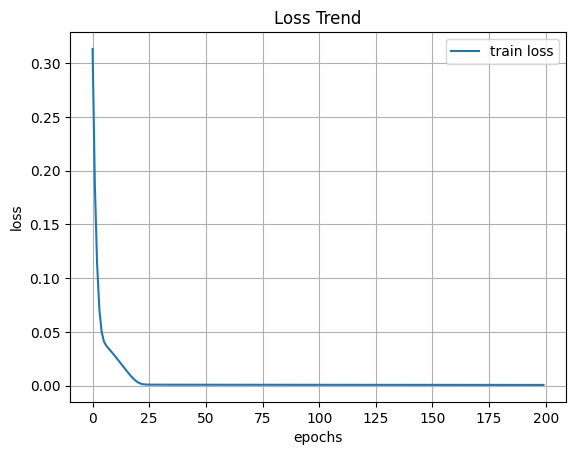

In [43]:
import matplotlib.pyplot as plt

plt.title('Loss Trend')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.grid()
plt.plot(train_loss_list, label='train loss')
plt.legend()
plt.show()

In [44]:
test_pred_tensor = model(x_test_tensor)

test_pred_numpy = test_pred_tensor.cpu().detach().numpy()

pred_inverse = scaler_y.inverse_transform(test_pred_numpy)

y_test_numpy = y_test_tensor.cpu().detach().numpy()

y_test_inverse = scaler_y.inverse_transform(y_test_numpy)

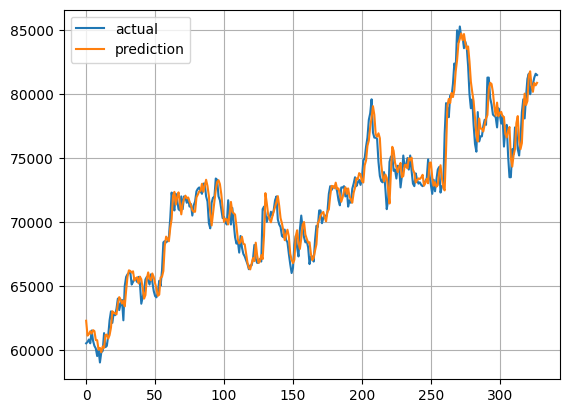

In [45]:
import matplotlib.pyplot as plt

plt.plot(y_test_inverse, label='actual')
plt.plot(pred_inverse, label='prediction')
plt.grid()
plt.legend()

plt.show()

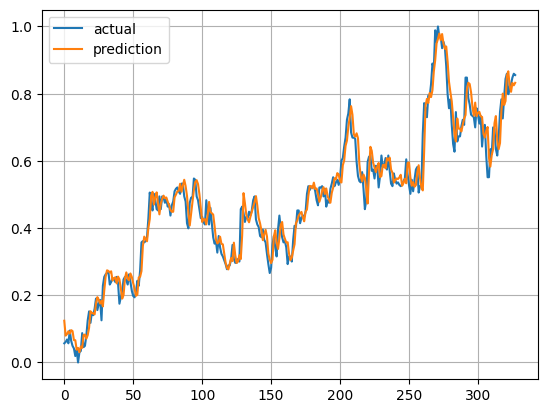

In [46]:
import matplotlib.pyplot as plt

plt.plot(y_test_numpy, label='actual')
plt.plot(test_pred_numpy, label='prediction')
plt.grid()
plt.legend()

plt.show()